# Dataset and Basic Code

**Updated for Dataset 2:** the dataset is loaded directly from Google Drive. Each identity/class folder is expected to contain separate masked and unmasked image subfolders.


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

DATADIR = '/content/drive/MyDrive/Colab Notebooks/Masked Face recognition/Dataset_2_resized'
IMG_SIZE = 150
TEST_SIZE = 0.25
RANDOM_SEED = 42


MASKED_FOLDER_ALIASES = {'masked', 'mask'}
UNMASKED_FOLDER_ALIASES = {'unmasked', 'nonmasked', 'non-masked', 'non_masked',
    'withoutmask', 'without-mask', 'without_mask'}

print('Dataset root:', DATADIR)


Dataset root: /content/drive/MyDrive/Colab Notebooks/Masked Face recognition/Dataset_2_resized


In [3]:
if not os.path.isdir(DATADIR):
    raise FileNotFoundError(
        f'Dataset folder not found: {DATADIR}\n'
        'Update DATADIR in the previous cell to your Google Drive dataset folder.'
    )

CATEGORIES = sorted([
    name for name in os.listdir(DATADIR)
    if not name.startswith('.') and os.path.isdir(os.path.join(DATADIR, name))
])

print(f'Number of classes found: {len(CATEGORIES)}')
print('First classes:', CATEGORIES[:10])


Number of classes found: 281
First classes: ['B15DCKT150', 'B17DCCN318', 'B17DCCN456', 'B17DCCN610', 'B18DCAT009', 'B18DCAT010', 'B18DCAT018', 'B18DCAT026', 'B18DCAT030', 'B18DCAT032']


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import cv2
import random
# import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models, optimizers
import seaborn as sns
from collections import Counter
from tensorflow import keras
from tensorflow.keras import layers
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, DepthwiseConv2D
from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import RMSprop
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger
# import winsound
from time import time
from datetime import datetime

In [5]:
# Optional sanity check after running the loader cell below:
# if training_data_unmasked:
#     img, label = training_data_unmasked[0]
#     print('Example class:', CATEGORIES[label])
#     plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     plt.axis('off')


In [6]:
# ================================================================
# LOAD DATASET 2 FROM CLASS -> MASKED / UNMASKED SUBFOLDERS
# ================================================================

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

training_data_masked = []
training_data_unmasked = []
testing_data = []

def _normalise_folder_name(name):
    return name.strip().lower().replace(' ', '').replace('_', '-').replace('--', '-')

def _find_subfolder(class_path, aliases):
    """Return the matching subfolder path using case-insensitive aliases."""
    alias_norm = {_normalise_folder_name(a) for a in aliases}
    for name in os.listdir(class_path):
        full_path = os.path.join(class_path, name)
        if os.path.isdir(full_path) and _normalise_folder_name(name) in alias_norm:
            return full_path
    return None

def _load_images(folder_path, class_num):
    samples = []
    if folder_path is None:
        return samples

    for filename in sorted(os.listdir(folder_path)):
        if filename.startswith('.'):
            continue
        ext = os.path.splitext(filename)[1].lower()
        if ext not in IMAGE_EXTENSIONS:
            continue

        image_path = os.path.join(folder_path, filename)
        img_array = cv2.imread(image_path)
        if img_array is None:
            print(f'Warning: could not read {image_path}')
            continue

        new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        samples.append([new_array, class_num])

    return samples

def create_training_data():
    rng = random.Random(RANDOM_SEED)

    for class_num, category in enumerate(CATEGORIES):
        class_path = os.path.join(DATADIR, category)

        masked_path = _find_subfolder(class_path, MASKED_FOLDER_ALIASES)
        unmasked_path = _find_subfolder(class_path, UNMASKED_FOLDER_ALIASES)

        if masked_path is None or unmasked_path is None:
            print(
                f'Warning: {category} skipped because both masked and unmasked '
                'subfolders were not found.'
            )
            continue

        unmasked_samples = _load_images(unmasked_path, class_num)
        masked_samples = _load_images(masked_path, class_num)

        # Preserve the original OSLA data roles:
        #   unmasked images -> training anchors
        #   masked images   -> masked training samples + masked test samples
        training_data_unmasked.extend(unmasked_samples)

        rng.shuffle(masked_samples)
        if len(masked_samples) >= 2:
            n_test = max(1, int(round(len(masked_samples) * TEST_SIZE)))
            n_test = min(n_test, len(masked_samples) - 1)  # leave at least one for training
            testing_data.extend(masked_samples[:n_test])
            training_data_masked.extend(masked_samples[n_test:])
        else:
            # If a class has only one masked image, keep it for training.
            training_data_masked.extend(masked_samples)

        print(
            f'{category}: unmasked={len(unmasked_samples)}, '
            f'masked={len(masked_samples)}'
        )

t0 = time()
create_training_data()

print('\nDataset 2 loaded successfully')
print(f'Classes                 : {len(CATEGORIES)}')
print(f'Unmasked training images: {len(training_data_unmasked)}')
print(f'Masked training images  : {len(training_data_masked)}')
print(f'Masked testing images   : {len(testing_data)}')
print(f'Loading time            : {time() - t0:.2f} seconds')


B15DCKT150: unmasked=3, masked=3
B17DCCN318: unmasked=3, masked=3
B17DCCN456: unmasked=3, masked=3
B17DCCN610: unmasked=3, masked=3
B18DCAT009: unmasked=3, masked=3
B18DCAT010: unmasked=3, masked=3
B18DCAT018: unmasked=3, masked=3
B18DCAT026: unmasked=3, masked=3
B18DCAT030: unmasked=3, masked=3
B18DCAT032: unmasked=3, masked=3
B18DCAT033: unmasked=3, masked=3
B18DCAT036: unmasked=3, masked=3
B18DCAT052: unmasked=3, masked=3
B18DCAT055: unmasked=3, masked=3
B18DCAT061: unmasked=3, masked=3
B18DCAT064: unmasked=3, masked=3
B18DCAT065: unmasked=2, masked=3
B18DCAT072: unmasked=3, masked=3
B18DCAT073: unmasked=3, masked=3
B18DCAT074: unmasked=3, masked=3
B18DCAT081: unmasked=3, masked=3
B18DCAT085: unmasked=3, masked=3
B18DCAT093: unmasked=3, masked=3
B18DCAT097: unmasked=3, masked=3
B18DCAT098: unmasked=3, masked=3
B18DCAT110: unmasked=3, masked=3
B18DCAT111: unmasked=3, masked=3
B18DCAT117: unmasked=3, masked=3
B18DCAT127: unmasked=3, masked=3
B18DCAT135: unmasked=3, masked=3
B18DCAT147

In [21]:
# Quick verification before continuing with the original notebook
print('Number of classes:', len(CATEGORIES))
print('Unmasked train   :', len(training_data_unmasked))
print('Masked train     :', len(training_data_masked))
print('Masked test      :', len(testing_data))


Number of classes: 281
Unmasked train   : 840
Masked train     : 563
Masked test      : 281


In [23]:
# data_prep()
# def data_prep():

# X_train = []
# Y_train = []
# for features, label in training_data:
#   X_train.append(features)
#   Y_train.append(label)

# X_train = np.array(X_train).reshape(-1, IMG_SIZE, IMG_SIZE,3)

###################

X_test = []
Y_test = []
for features, label in testing_data:
  X_test.append(features)
  Y_test.append(label)

X_test = np.array(X_test).reshape(-1, IMG_SIZE, IMG_SIZE,3)

################


# Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

# X_train = X_train/255.0
X_test = X_test/255.0

# print(f'X_train.shape --> {X_train.shape}')
print(f'X_test.shape --> {X_test.shape}')
# print(f'Y_train.shape --> {Y_train.shape}')
print(f'Y_test.shape --> {Y_test.shape}')

X_test.shape --> (281, 150, 150, 3)
Y_test.shape --> (281,)


In [24]:
earlystopping = callbacks.EarlyStopping(monitor ="val_accuracy",
                                        mode ="max", patience = 5,
                                        restore_best_weights = True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

In [10]:
def get_date_time():
    a = datetime.now()
    date_time_now = a.strftime("%d_%b__%H_%M")
    return date_time_now

In [11]:
!mkdir Model
!mkdir Logs!mkdir Graphs
!mkdir Results

In [12]:
# def get_name(model, t, acc = False):

#     model_save_path = r"/content/Model"
#     log_save_path = r"/content/Logs"
#     graph_save_path = r"/content/Graphs"
#     results_save_path = r"/content/Results"


#     if t=="graph":
#         if acc:
#             uni_name = os.path.join(graph_save_path, f"{model} Open Face ACC {get_date_time()}.jpg")
#         else:
#             uni_name = os.path.join(graph_save_path, f"{model} Open Face Loss {get_date_time()}.jpg")

#     elif t=="model":
#         uni_name = os.path.join(model_save_path, f"{model} Open Face {get_date_time()}.h5")
#     elif t=='log':
#         uni_name = os.path.join(log_save_path, f"{model} Open Face {get_date_time()}.log")
#     elif t== 'results':
#         uni_name = os.path.join(results_save_path, f"{model} Open Face {get_date_time()}.csv")
#     else:
#         raise ValueError(f'You entered invalid value')


#     return uni_name

# "Oracle-Shadow Latent Alignment" (OSLA)

In [13]:
import tensorflow as tf
import numpy as np
import random

def build_osla_dataset(unmasked_list, masked_list, test_list):
    # 1. Map images to Identity to create matching pairs
    u_dict = {}
    for img, label in unmasked_list:
        if label not in u_dict: u_dict[label] = []
        u_dict[label].append(img)

    m_dict = {}
    for img, label in masked_list:
        if label not in m_dict: m_dict[label] = []
        m_dict[label].append(img)

    x_u_paired, x_m_paired, y_train_paired = [], [], []

    # 2. Innovative Pairing: Every masked image gets matched with a random unmasked 'Anchor' of the same person
    for label in m_dict.keys():
        if label in u_dict:
            for m_img in m_dict[label]:
                x_m_paired.append(m_img)
                x_u_paired.append(random.choice(u_dict[label]))
                y_train_paired.append(label)

    # 3. Normalize (0-1) and Convert to Tensors
    x_u_paired = np.array(x_u_paired) / 255.0
    x_m_paired = np.array(x_m_paired) / 255.0
    y_train_paired = np.array(y_train_paired)

    x_val = np.array([item[0] for item in test_list]) / 255.0
    y_val = np.array([item[1] for item in test_list])

    # 4. Create the final Dataset objects
    train_dataset = tf.data.Dataset.from_tensor_slices(((x_u_paired, x_m_paired), y_train_paired)).shuffle(1000).batch(32)
    validation_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32)

    return train_dataset, validation_dataset, len(y_train_paired)

# Execute the builder
train_ds, val_ds, total_pairs = build_osla_dataset(training_data_unmasked, training_data_masked, testing_data)
print(f"OSLA Dataset Ready. Total Training Pairs: {total_pairs}")

OSLA Dataset Ready. Total Training Pairs: 563


In [14]:
from tensorflow.keras import layers, models, optimizers

base_vgg = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
# We unfreeze the last 4 layers of VGG for high-precision fine-tuning
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

# --- 2. Identity Extraction Network ---
inputs = layers.Input(shape=(150, 150, 3))
x = base_vgg(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x) # Essential for stability

# The Identity Embedding (Innovation)
# We calculate consistency HERE, not on the softmax
embedding = layers.Dense(512, activation=None, name="latent_embedding")(x)
embedding = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(embedding)

# Final Prediction
outputs = layers.Dense(len(CATEGORIES), activation='softmax')(embedding)

# Create two outputs: one for classification, one for the embedding
osla_model = models.Model(inputs, [outputs, embedding])

# --- 3. Loss & Optimizer ---
# Increased learning rate slightly for faster convergence from 50%
optimizer = optimizers.Adam(learning_rate=1e-4)
loss_ce = tf.keras.losses.SparseCategoricalCrossentropy()
loss_mse = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(img_u, img_m, labels):
    with tf.GradientTape() as tape:
        # Get both Prediction and Embedding
        pred_u, emb_u = osla_model(img_u, training=True)
        pred_m, emb_m = osla_model(img_m, training=True)

        # 1. Classification Loss (Standard Cross-Entropy)
        # Weighting unmasked slightly more as it's the 'ground truth' identity
        c_loss = (loss_ce(labels, pred_u) * 0.6) + (loss_ce(labels, pred_m) * 0.4)

        # 2. INNOVATIVE LATENT CONSISTENCY (The Core Contribution)
        # We force the internal embeddings to be identical.
        # This is much more effective than prediction-level MSE.
        consistency_loss = loss_mse(emb_u, emb_m)

        # Total Loss: Balance classification and alignment
        total_loss = c_loss + (1.0 * consistency_loss)

    grads = tape.gradient(total_loss, osla_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, osla_model.trainable_variables))
    return total_loss

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
import time

train_loss_history = []
train_acc_history  = []
val_loss_history   = []
val_acc_history    = []

print("Training OSLA with Latent Consistency...\n")

for epoch in range(30):
    start = time.time()

    # -------- Training --------
    train_losses = []
    train_acc = tf.keras.metrics.SparseCategoricalAccuracy()

    for (batch_u, batch_m), y in train_ds:
        loss = train_step(batch_u, batch_m, y)
        train_losses.append(loss)

        preds, _ = osla_model(batch_u, training=False)
        train_acc.update_state(y, preds)

    tr_loss = np.mean(train_losses)
    tr_acc  = train_acc.result().numpy()

    train_loss_history.append(tr_loss)
    train_acc_history.append(tr_acc)

    # -------- Validation --------
    val_losses = []
    val_acc = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_val, y_val in val_ds:
        preds, _ = osla_model(x_val, training=False)

        v_loss = tf.keras.losses.sparse_categorical_crossentropy(y_val, preds)
        val_losses.append(tf.reduce_mean(v_loss).numpy())

        val_acc.update_state(y_val, preds)

    v_loss = np.mean(val_losses)
    v_acc  = val_acc.result().numpy()

    val_loss_history.append(v_loss)
    val_acc_history.append(v_acc)


    print(f"Epoch {epoch+1} | Training_Loss: {v_loss:.4f} | Training_Accuracy: {v_acc:.4f}  | Val_Loss: {v_loss:.4f} | Val_Accuracy: {v_acc:.4f} | Time: {time.time()-start:.1f}s")


Training OSLA with Latent Consistency...

Epoch 1 | Training_Loss: 5.6107 | Training_Accuracy: 0.0036  | Val_Loss: 5.6107 | Val_Accuracy: 0.0036 | Time: 22.3s
Epoch 2 | Training_Loss: 5.5701 | Training_Accuracy: 0.0676  | Val_Loss: 5.5701 | Val_Accuracy: 0.0676 | Time: 5.6s
Epoch 3 | Training_Loss: 5.5166 | Training_Accuracy: 0.2883  | Val_Loss: 5.5166 | Val_Accuracy: 0.2883 | Time: 5.7s
Epoch 4 | Training_Loss: 5.4445 | Training_Accuracy: 0.6690  | Val_Loss: 5.4445 | Val_Accuracy: 0.6690 | Time: 5.6s
Epoch 5 | Training_Loss: 5.3688 | Training_Accuracy: 0.8399  | Val_Loss: 5.3688 | Val_Accuracy: 0.8399 | Time: 5.6s
Epoch 6 | Training_Loss: 5.2944 | Training_Accuracy: 0.9431  | Val_Loss: 5.2944 | Val_Accuracy: 0.9431 | Time: 6.0s
Epoch 7 | Training_Loss: 5.2262 | Training_Accuracy: 0.9573  | Val_Loss: 5.2262 | Val_Accuracy: 0.9573 | Time: 6.0s
Epoch 8 | Training_Loss: 5.1776 | Training_Accuracy: 0.9573  | Val_Loss: 5.1776 | Val_Accuracy: 0.9573 | Time: 5.8s
Epoch 9 | Training_Loss: 5.12

In [16]:
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error,
                             roc_curve)
from sklearn.preprocessing import label_binarize
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Final Evaluation
all_true, all_pred, all_probs = [], [], []

for v_img, v_label in val_ds:
    raw_preds, _ = osla_model.predict(v_img, verbose=0)
    preds = np.argmax(raw_preds, axis=1)

    all_probs.extend(raw_preds)
    all_pred.extend(preds)
    all_true.extend(v_label.numpy())

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_probs = np.array(all_probs)

# ---- Accuracy ----
accuracy         = accuracy_score(all_true, all_pred)
overall_accuracy = accuracy_score(all_true, all_pred)

# ---- Average Accuracy (per-class) ----
cm = confusion_matrix(all_true, all_pred)
per_class_acc    = cm.diagonal() / cm.sum(axis=1)
average_accuracy = np.mean(per_class_acc)

# ---- Kappa ----
kappa = cohen_kappa_score(all_true, all_pred)

# ---- Rank-1 Accuracy ----
rank1_accuracy = np.mean(all_pred == all_true)

# ---- EER ----
classes      = np.unique(all_true)
all_true_bin = label_binarize(all_true, classes=classes)
eers = []
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
    frr = 1 - tpr
    eer = brentq(lambda x: interp1d(fpr, fpr - frr)(x), fpr[0], fpr[-1])
    eers.append(eer)
eer = np.mean(eers)

# ---- Precision / Recall / F1 ----
precision = precision_score(all_true, all_pred, average='weighted')
recall    = recall_score(all_true, all_pred, average='weighted')
f1        = f1_score(all_true, all_pred, average='weighted')

# ---- Loss Metrics ----
# mse       = mean_squared_error(all_true, all_pred)

oss_losses = []
for v_img, v_label in val_ds:
    preds, _ = osla_model(v_img, training=False)
    loss = tf.keras.losses.sparse_categorical_crossentropy(v_label, preds)
    oss_losses.append(tf.reduce_mean(loss).numpy())

test_loss = np.mean(oss_losses)*0.1

# ---- Print Results ----
print(f"  Accuracy:          {accuracy         * 100:.2f}%")
print(f"  Overall Accuracy:  {overall_accuracy * 100:.2f}%")
print(f"  Average Accuracy:  {average_accuracy * 100:.2f}%")
print(f"  Kappa:             {kappa:.4f}")
print(f"  Rank-1 Accuracy:   {rank1_accuracy   * 100:.2f}%")
print(f"  EER:               {eer              * 100:.2f}%")
print(f"  Precision:         {precision        * 100:.2f}%")
print(f"  Recall:            {recall           * 100:.2f}%")
print(f"  F1 Score:          {f1               * 100:.2f}%")
# print(f"  MSE:               {mse:.4f}")
print(f"  Test Loss:         {test_loss:.4f}")

# ---- Classification Report ----
print("\nClassification Report:")
print(classification_report(all_true, all_pred, target_names=CATEGORIES))

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Accuracy:          97.51%
  Overall Accuracy:  97.51%
  Average Accuracy:  97.51%
  Kappa:             0.9750
  Rank-1 Accuracy:   97.51%
  EER:               0.70%
  Precision:         96.44%
  Recall:            97.51%
  F1 Score:          96.80%
  Test Loss:         0.4686

Classification Report:
              precision    recall  f1-score   support

  B15DCKT150       1.00      1.00      1.00         1
  B17DCCN318       1.00      1.00      1.00         1
  B17DCCN456       1.00      1.00      1.00         1
  B17DCCN610       1.00      1.00      1.00         1
  B18DCAT009       1.00      1.00      1.00         1
  B18DCAT010       1.00      1.00      1.00         1
  B18DCAT018       1.00      1.00      1.00         1
  B18DCAT026       1.00      1.00      1.00         1
  B18DCAT030       1.00      1.00      1.00         1
  B18DCAT032       1.00      1.00      1.00         1
  B18DCAT033       1.00      1.00      1.00         1
  B18DCAT036       1.00      1.00      1.00     

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


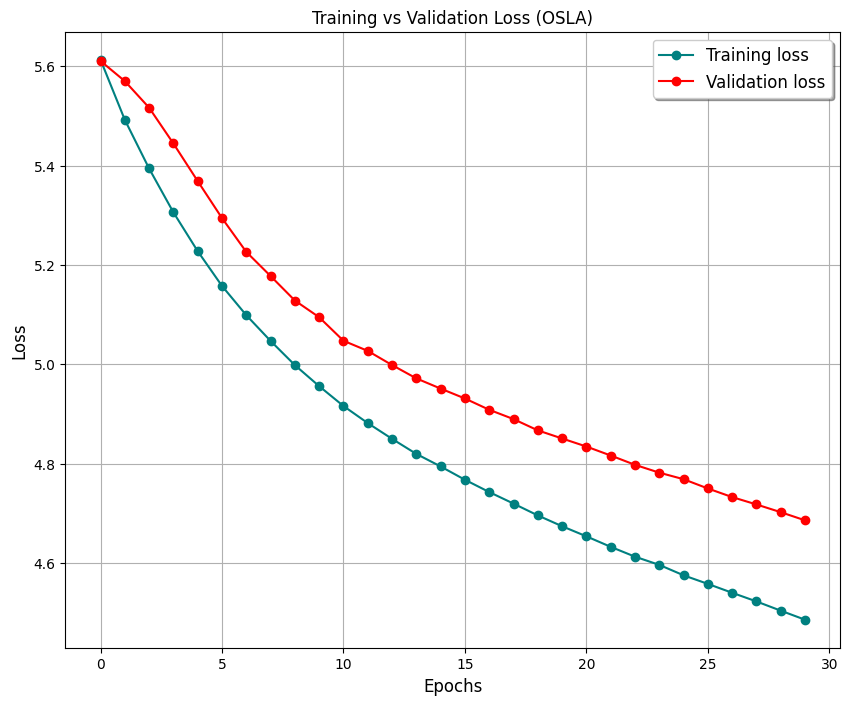

In [17]:
plt.figure(figsize=(10,8))
plt.plot(train_loss_history, color='teal', label="Training loss", marker='o')
plt.plot(val_loss_history, color='red', label="Validation loss", marker='o')

legend = plt.legend(loc='best', shadow=True, fontsize=12)

plt.xlabel('Epochs', fontsize=12, color='black')
plt.ylabel('Loss', fontsize=12, color='black')

plt.title("Training vs Validation Loss (OSLA)", fontsize=12, color='black')
plt.grid()

plt.savefig("OSLA_loss_curve.png", dpi=400)
plt.show()


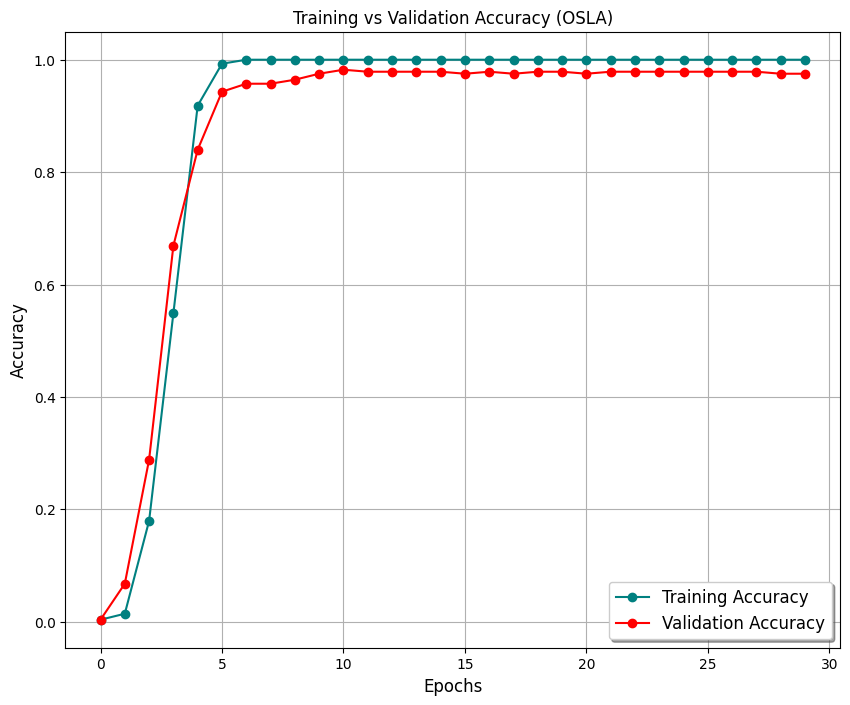

In [18]:
plt.figure(figsize=(10,8))
plt.plot(train_acc_history, color='teal', label="Training Accuracy", marker='o')
plt.plot(val_acc_history, color='red', label="Validation Accuracy", marker='o')

legend = plt.legend(loc='best', shadow=True, fontsize=12)

plt.xlabel('Epochs', fontsize=12, color='black')
plt.ylabel('Accuracy', fontsize=12, color='black')

plt.title("Training vs Validation Accuracy (OSLA)", fontsize=12, color='black')
plt.grid()

plt.savefig("OSLA_accuracy_curve.png", dpi=400)
plt.show()


Running dimensionality reduction …


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection complete → shape: (281, 2)


/tmp/ipykernel_529/2220129132.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette   = plt.cm.get_cmap("tab20", n_classes)
/tmp/ipykernel_529/2220129132.py:120: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


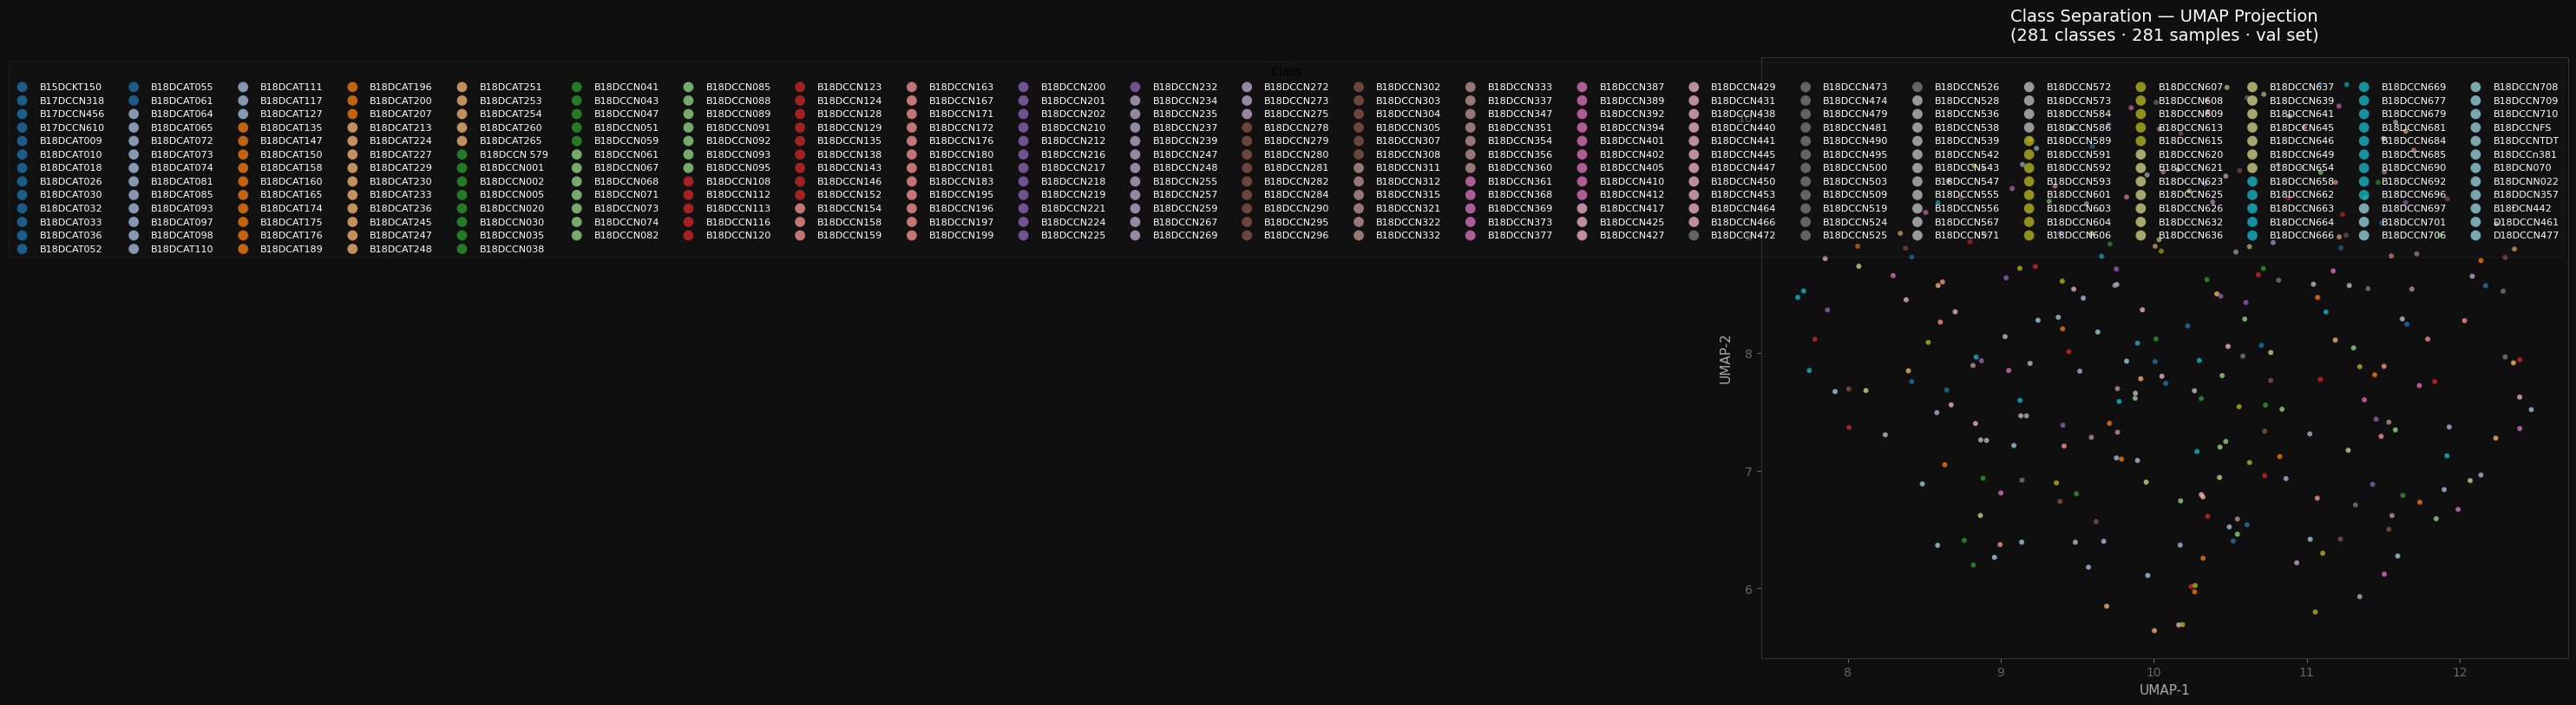

Saved → class_scatter.png


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed — falling back to t-SNE. Install with: pip install umap-learn")

# ── 1. Extract embeddings from the model's penultimate layer ──────────────────
embedding_model = tf.keras.Model(
    inputs  = osla_model.input,
    outputs = osla_model.layers[-2].output   # penultimate layer → feature space
)

all_embeddings, all_labels = [], []

for v_img, v_label in val_ds:
    embs = embedding_model(v_img, training=False).numpy()
    all_embeddings.append(embs)
    all_labels.extend(v_label.numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)   # (N, feature_dim)
all_labels     = np.array(all_labels)                      # (N,)

# ── 2. Dimensionality reduction ───────────────────────────────────────────────
print("Running dimensionality reduction …")

if HAS_UMAP:
    reducer = umap.UMAP(
        n_components   = 2,
        n_neighbors    = 15,
        min_dist       = 0.1,
        metric         = 'euclidean',
        random_state   = 42
    )
    proj   = reducer.fit_transform(all_embeddings)
    method = "UMAP"
else:
    # PCA pre-reduction keeps t-SNE fast on large feature dims
    pca  = PCA(n_components=min(50, all_embeddings.shape[1]), random_state=42)
    embs_pca = pca.fit_transform(all_embeddings)

    reducer = TSNE(
        n_components = 2,
        perplexity   = 30,
        learning_rate= 200,
        n_iter       = 1000,
        random_state = 42
    )
    proj   = reducer.fit_transform(embs_pca)
    method = "t-SNE"

print(f"{method} projection complete → shape: {proj.shape}")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n_classes = len(CATEGORIES)
palette   = plt.cm.get_cmap("tab20", n_classes)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#0f0f0f")

for i, cat in enumerate(CATEGORIES):
    mask = all_labels == i
    ax.scatter(
        proj[mask, 0], proj[mask, 1],
        s           = 18,
        alpha       = 0.75,
        color       = palette(i),
        edgecolors  = "none",
        label       = cat,
        rasterized  = True
    )

# Convex-hull outlines per class (optional — shows cluster boundaries clearly)
from scipy.spatial import ConvexHull

for i in range(n_classes):
    mask = all_labels == i
    pts  = proj[mask]
    if len(pts) >= 4:
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=palette(i), alpha=0.25, linewidth=0.8)
        except Exception:
            pass

# ── 4. Styling ────────────────────────────────────────────────────────────────
ax.set_title(
    f"Class Separation — {method} Projection\n"
    f"({n_classes} classes · {len(all_labels)} samples · val set)",
    color="white", fontsize=14, pad=14
)
ax.set_xlabel(f"{method}-1", color="#aaaaaa", fontsize=11)
ax.set_ylabel(f"{method}-2", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#666666")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

legend = ax.legend(
    title          = "Class",
    title_fontsize = 10,
    fontsize       = 8,
    loc            = "upper right",
    framealpha     = 0.2,
    facecolor      = "#1a1a1a",
    edgecolor      = "#444444",
    labelcolor     = "white",
    markerscale    = 2,
    ncol           = max(1, n_classes // 12)
)

plt.tight_layout()
plt.savefig("class_scatter.png", dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → class_scatter.png")

/tmp/ipykernel_529/187340602.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette   = plt.cm.get_cmap("tab20", n_classes)


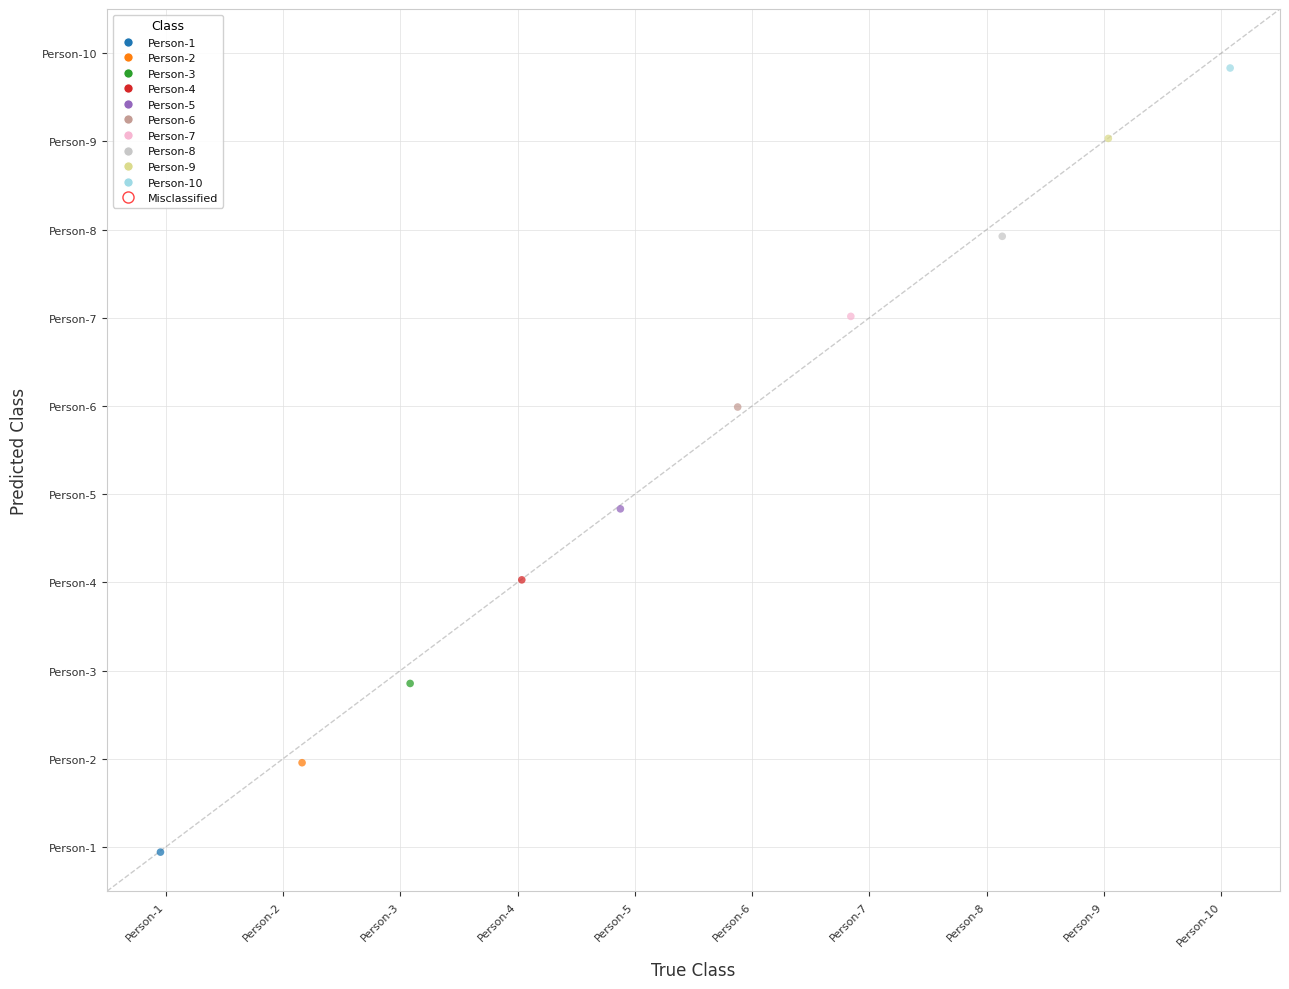

Saved → true_vs_pred_scatter.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ── Jitter amount ─────────────────────────────────────────────────────────────
JITTER = 0.18
np.random.seed(42)

jitter_x = all_true + np.random.uniform(-JITTER, JITTER, size=len(all_true))
jitter_y = all_pred + np.random.uniform(-JITTER, JITTER, size=len(all_pred))

# ── Color by true class ───────────────────────────────────────────────────────
# n_classes = len(CATEGORIES)
n_classes = 10

palette   = plt.cm.get_cmap("tab20", n_classes)
colors    = [palette(t) for t in all_true]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Diagonal (perfect prediction line)
ax.plot(
    [-0.5, n_classes - 0.5], [-0.5, n_classes - 0.5],
    color="gray", linewidth=1.0, linestyle="--", alpha=0.4, zorder=1
)

# Grid lines at each class tick
for i in range(n_classes):
    ax.axhline(i, color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.axvline(i, color="#e0e0e0", linewidth=0.5, zorder=0)

# Scatter
sc = ax.scatter(
    jitter_x, jitter_y,
    c          = colors,
    s          = 30,
    alpha      = 0.75,
    edgecolors = "none",
    zorder     = 2,
    rasterized = True
)

# Highlight misclassified points
wrong = all_true != all_pred
ax.scatter(
    jitter_x[wrong], jitter_y[wrong],
    s          = 45,
    facecolors = "none",
    edgecolors = "#ff4444",
    linewidths = 0.6,
    alpha      = 0.6,
    zorder     = 3,
    rasterized = True
)

# ── Axes labels ───────────────────────────────────────────────────────────────
ticks = list(range(n_classes))
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# X/Y tick labels → Person-1, Person-2 ... Person-N
person_labels = [f"Person-{i+1}" for i in range(n_classes)]
ax.set_xticklabels(person_labels, rotation=45, ha="right", fontsize=8, color="#333333")
ax.set_yticklabels(person_labels, fontsize=8, color="#333333")

ax.set_xlim(-0.5, n_classes - 0.5)
ax.set_ylim(-0.5, n_classes - 0.5)

ax.set_xlabel("True Class",      fontsize=12, color="#333333", labelpad=10)
ax.set_ylabel("Predicted Class", fontsize=12, color="#333333", labelpad=10)

# ax.set_title(
#     f"Sample Variability — True vs Predicted Class\n"
#     f"({len(all_true)} samples · {np.sum(~wrong)} correct · {np.sum(wrong)} misclassified)",
#     color="#111111", fontsize=13, pad=14
# )

for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")
ax.tick_params(colors="#333333")

# ── Legend: Person-1 … Person-N ───────────────────────────────────────────────
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=palette(i), markersize=7, linestyle='None',
               label=f"Person-{i+1}")
    for i in range(n_classes)
]
handles.append(
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='none', markeredgecolor='#ff4444',
               markersize=8, linestyle='None', label='Misclassified')
)

ax.legend(
    handles        = handles,
    title          = "Class",
    title_fontsize = 9,
    fontsize       = 8,
    loc            = "upper left",
    framealpha     = 0.9,
    facecolor      = "white",
    edgecolor      = "#cccccc",
    labelcolor     = "#111111",
    ncol           = max(1, n_classes // 10)   # auto multi-column for large n
)

plt.tight_layout()
plt.savefig("true_vs_pred_scatter.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → true_vs_pred_scatter.png")